# Tutorial 06 - Visualize Phases, VisualizationConfig, visualization_config_wrapper

## Step 0: Setup the project and prepare the data

In [1]:
from pathlib import Path

import pydpeet as eet

We will use "ERROR" as the logging style for better readability of the notebook

In [2]:
eet.set_logging_style("ERROR")

In [3]:
standardized_data = eet.read(
    input_path=str(Path.cwd().parent.parent / "res" / "raw_data_from_cyclers" / "Cal_Ageing_Checkup1.xlsx"),
    config=eet.ReadConfig.Neware_8_0_0_516,
)

In [4]:
segmented_data = eet.add_primitive_segments(df=standardized_data, config=eet.PrimitiveConfig.OCV_ANALYSIS_DEFAULT)

## Step 1: Visualize Phases

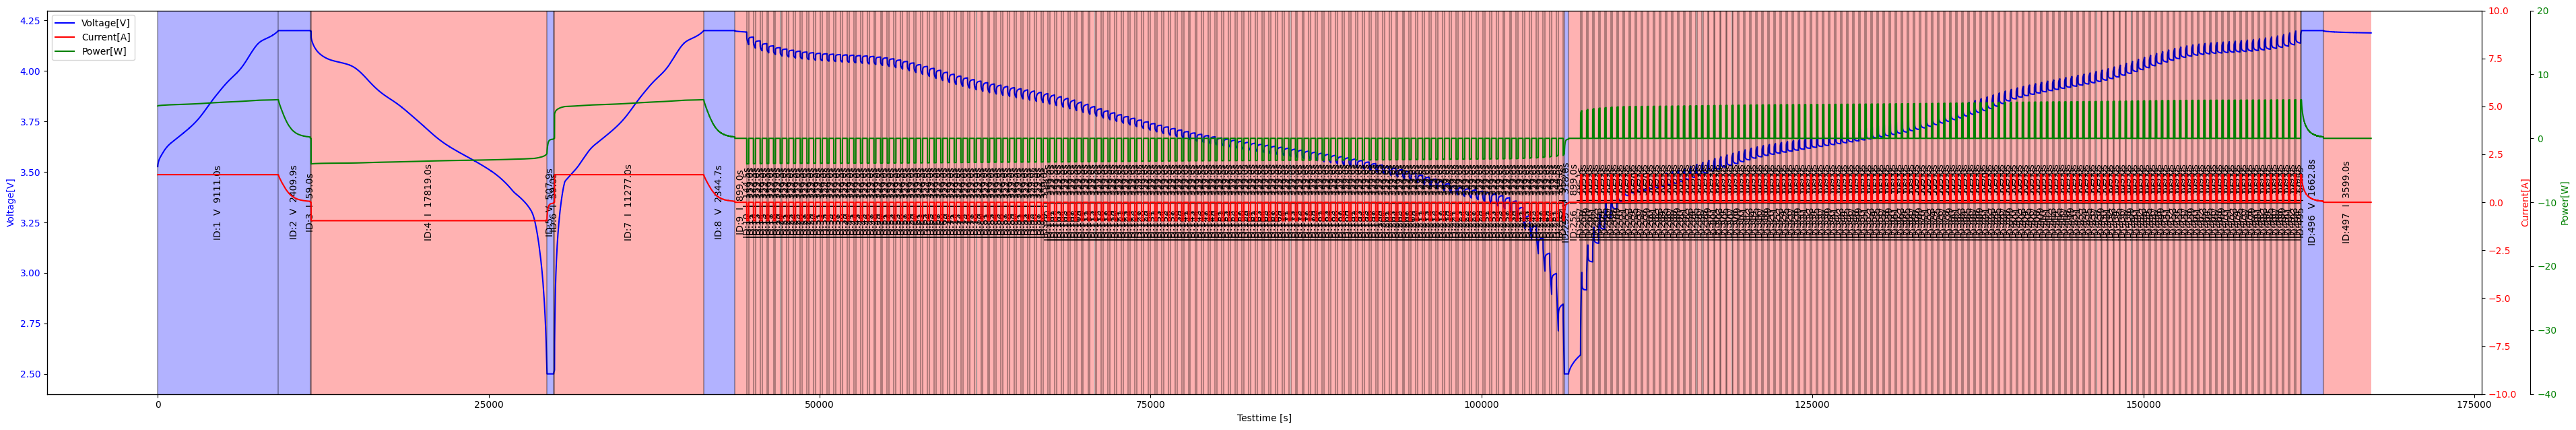

In [5]:
eet.visualize_phases(df=segmented_data, config=eet.VisualizationConfig.DEFAULT)

## Step 2: Visualize Phases with a custom configuration

A VisualizationConfig has the following parameters:

<div class="alert alert-block alert-info">
<b>Hint:</b> You can type in "eet.VisualizationConfig." to see all other availiable VisualizationConfig in most IDEs
</div>

In [6]:
eet.VisualizationConfig.DEFAULT

_VisualizationConfigClass(visualize_phases_config=[('V', 'blue'), ('I', 'red'), ('P', 'green')], line_visualization_config=[('Voltage[V]', 'blue', (2.4, 4.3)), ('Current[A]', 'red', (-10, 10)), ('Power[W]', 'green', (-40, 20))], start=0, end=1e+100, use_lines_for_segments=True, show_column_names=True, show_time=True, show_id=True, show_runtime=True, segment_alpha=0.3, width_height_ratio=[1, 0.3], end_condition_map_generate_instructions={'CC': 'voltage', 'CV': 'current', 'CP': 'voltage', 'Pause': 'time'}, standard_columns=['Test_Time[s]', 'Voltage[V]', 'Current[A]'])

<div class="alert alert-block alert-info">
<b>Hint:</b> Use visualization_config_wrapper to create your own custom VisualizationConfig that overwrites the standard values
</div>

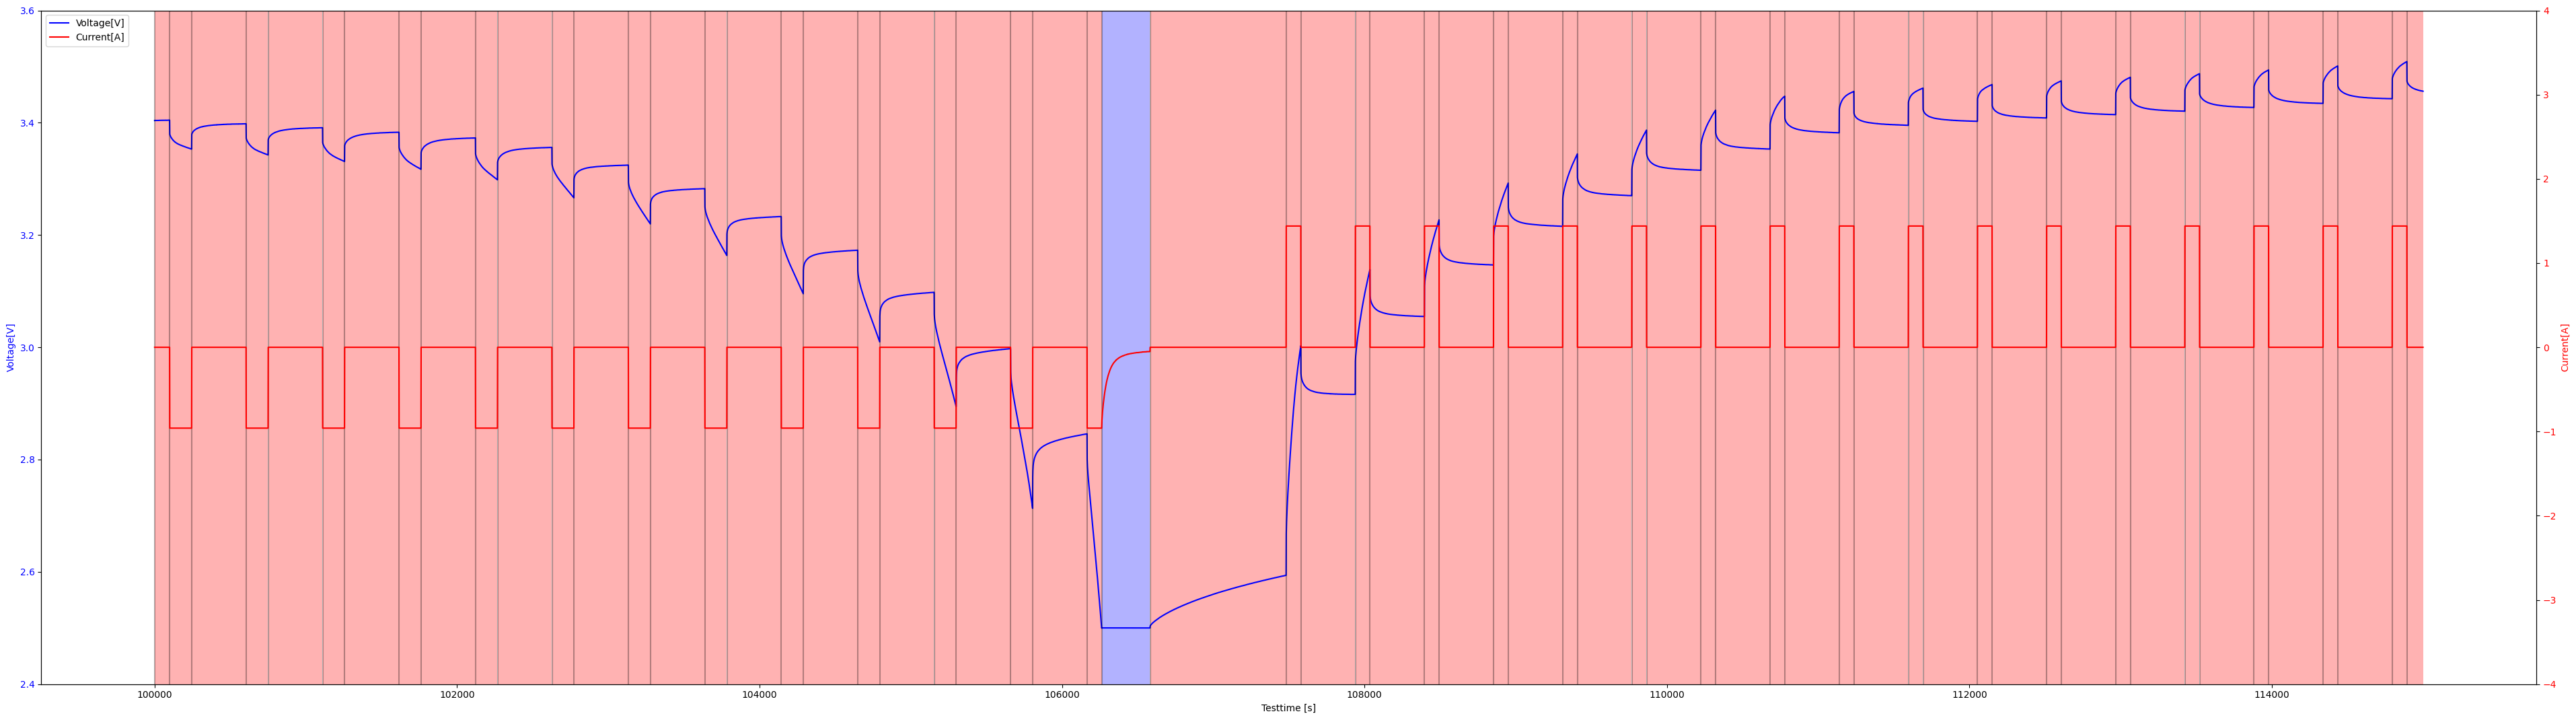

In [7]:
import matplotlib.pyplot as plt

eet.visualize_phases(
    df=segmented_data,
    config=eet.visualization_config_wrapper(  # overwritten the default values
        start=100000,
        end=115000,
        width_height_ratio=[1, 0.5],
        visualize_phases_config=[
            ("V", "blue"),
            ("I", "red"),
        ],
        line_visualization_config=[
            ("Voltage[V]", "blue", (2.4, 3.6)),
            ("Current[A]", "red", (-4, 4)),
        ],
        show_id=False,
        show_time=False,
        show_column_names=False,
    ),
)
plt.show()